In [ ]:
# Necessary libraies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,AdaBoostClassifier,GradientBoostingClassifier,BaggingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report,ConfusionMatrixDisplay,accuracy_score

import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/loan_risk_prediction_dataset.csv')

In [ ]:
df.head()

,Age,Income,LoanAmount,CreditScore,YearsExperience,Gender,Education,City,EmploymentType,LoanApproved
0,56,48353.0,31258.0,675.0,20,Female,High School,Houston,Unemployed,0
1,69,57462.0,23262.0,586.0,6,Male,High School,San Francisco,Self-Employed,0
2,46,44219.0,26530.0,781.0,26,Male,PhD,Houston,Self-Employed,1
3,32,56307.0,11531.0,549.0,11,Male,NaN,New York,Unemployed,0
4,60,37034.0,27871.0,500.0,19,Female,High School,Chicago,Unemployed,0


In [ ]:
df.shape

(5000, 10)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Age              5000 non-null   int64  
 1   Income           4804 non-null   float64
 2   LoanAmount       5000 non-null   float64
 3   CreditScore      4806 non-null   float64
 4   YearsExperience  5000 non-null   int64  
 5   Gender           5000 non-null   object 
 6   Education        4802 non-null   object 
 7   City             5000 non-null   object 
 8   EmploymentType   5000 non-null   object 
 9   LoanApproved     5000 non-null   int64  
dtypes: float64(3), int64(3), object(4)
memory usage: 390.8+ KB


In [ ]:
df.isnull().sum()

,0
Age,0
Income,196
LoanAmount,0
CreditScore,194
YearsExperience,0
Gender,0
Education,198
City,0
EmploymentType,0
LoanApproved,0


In [ ]:
for col in df.columns:
  print(f'\n{col}:')
  print(df[col].unique())


Age:
[56 69 46 32 60 25 38 36 40 28 41 53 57 20 39 19 61 47 55 50 29 42 66 44
 59 45 33 64 68 54 24 26 35 21 31 67 43 37 52 34 23 51 27 48 65 62 58 18
 22 30 49 63]

Income:
[48353. 57462. 44219. ... 58100. 58513. 58928.]

LoanAmount:
[31258. 23262. 26530. ... 18230. 12373. 23615.]

CreditScore:
[675. 586. 781. 549. 500. 835. 760. 599. 777. 382. 757. 597. 663.  nan
 639. 815. 407. 615. 413. 466. 560. 523. 561. 550. 825. 425. 505. 439.
 361. 582. 353. 645. 823. 435. 629. 443. 735. 581. 788. 700. 748. 569.
 316. 568. 518. 618. 537. 844. 584. 336. 402. 729. 538. 424. 487. 555.
 829. 691. 767. 552. 475. 765. 588. 349. 303. 799. 522. 834. 360. 655.
 323. 592. 328. 656. 664. 708. 565. 590. 452. 472. 311. 661. 776. 381.
 740. 525. 670. 327. 315. 576. 632. 782. 587. 337. 753. 465. 504. 544.
 695. 420. 558. 709. 609. 367. 519. 772. 685. 704. 791. 727. 514. 679.
 513. 397. 827. 848. 627. 464. 415. 449. 817. 331. 476. 715. 306. 384.
 697. 692. 346. 640. 725. 814. 428. 548. 430. 622. 842. 365. 40

In [ ]:
df['Income'] = df['Income'].fillna(round(df['Income'].mean(),0))

In [ ]:
df['CreditScore'] = df['CreditScore'].fillna(round(df['CreditScore'].mean(),0))

In [ ]:
df['Education'] = df['Education'].fillna(df['Education'].mode()[0])

In [ ]:
df_num = df.drop(['Gender','Education','City','EmploymentType'],axis=1)

### Univariate analysis

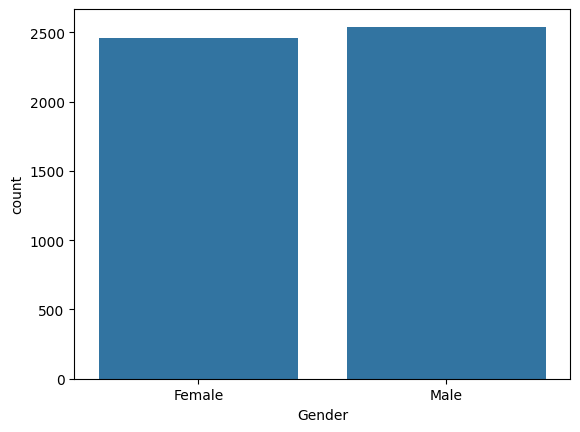

In [ ]:
sns.countplot(x='Gender',data=df);

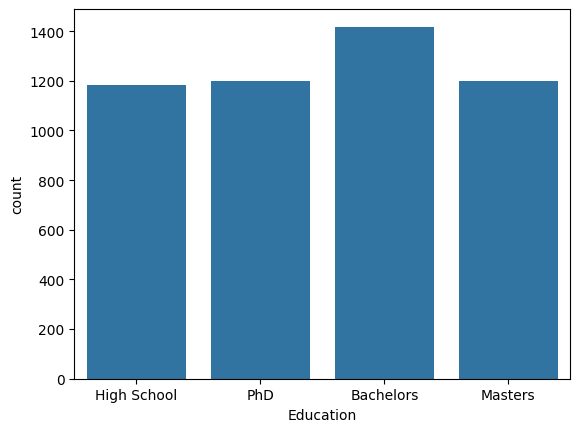

In [ ]:
sns.countplot(x='Education',data=df);

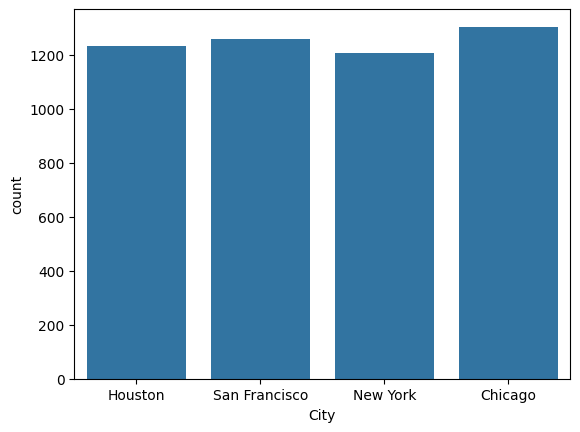

In [ ]:
sns.countplot(x='City',data=df);

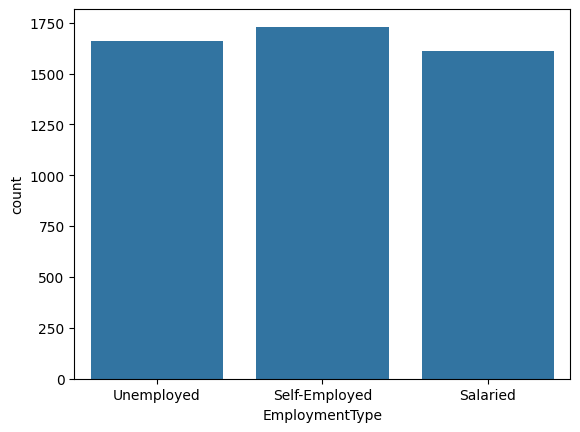

In [ ]:
sns.countplot(x='EmploymentType',data=df);

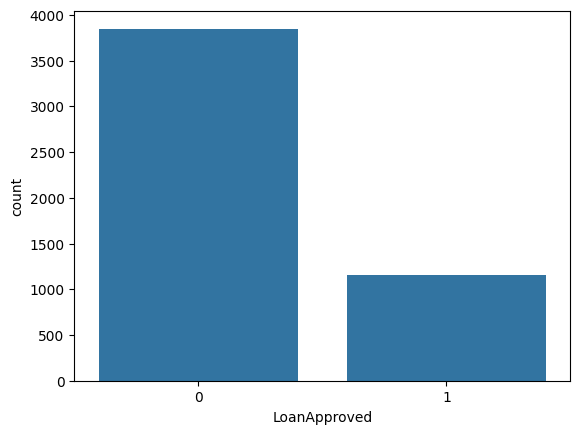

In [ ]:
sns.countplot(x='LoanApproved',data=df);

In [ ]:
df['LoanApproved'].value_counts()

,count
LoanApproved,
0,3849
1,1151


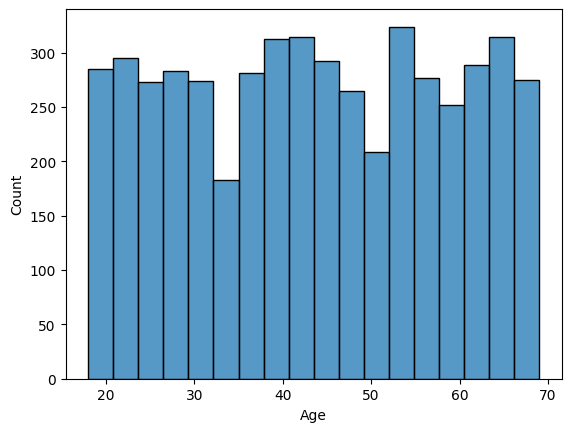

In [ ]:
sns.histplot(x='Age',data=df);

### Bivariate analysis



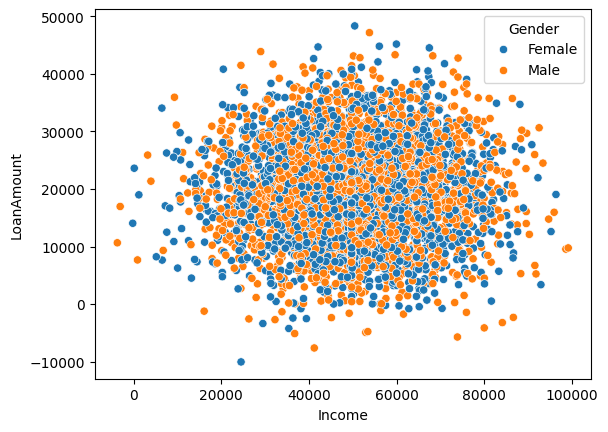

In [ ]:
sns.scatterplot(x='Income',y='LoanAmount',data=df,hue='Gender');

<Axes: xlabel='Gender', ylabel='CreditScore'>

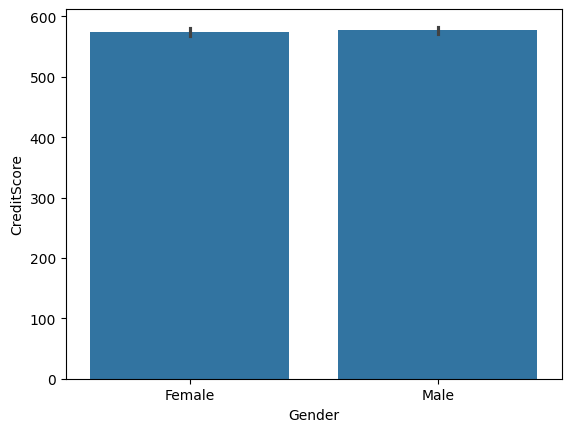

In [ ]:
sns.barplot(x='Gender',y='CreditScore',data=df)

### Multivariate analysis

In [ ]:
cat_col = df.select_dtypes(include='object').columns.to_list()
cat_col

['Gender', 'Education', 'City', 'EmploymentType']

In [ ]:
num_col = df.select_dtypes(exclude='object').columns.to_list()
num_col

['Age',
 'Income',
 'LoanAmount',
 'CreditScore',
 'YearsExperience',
 'LoanApproved']

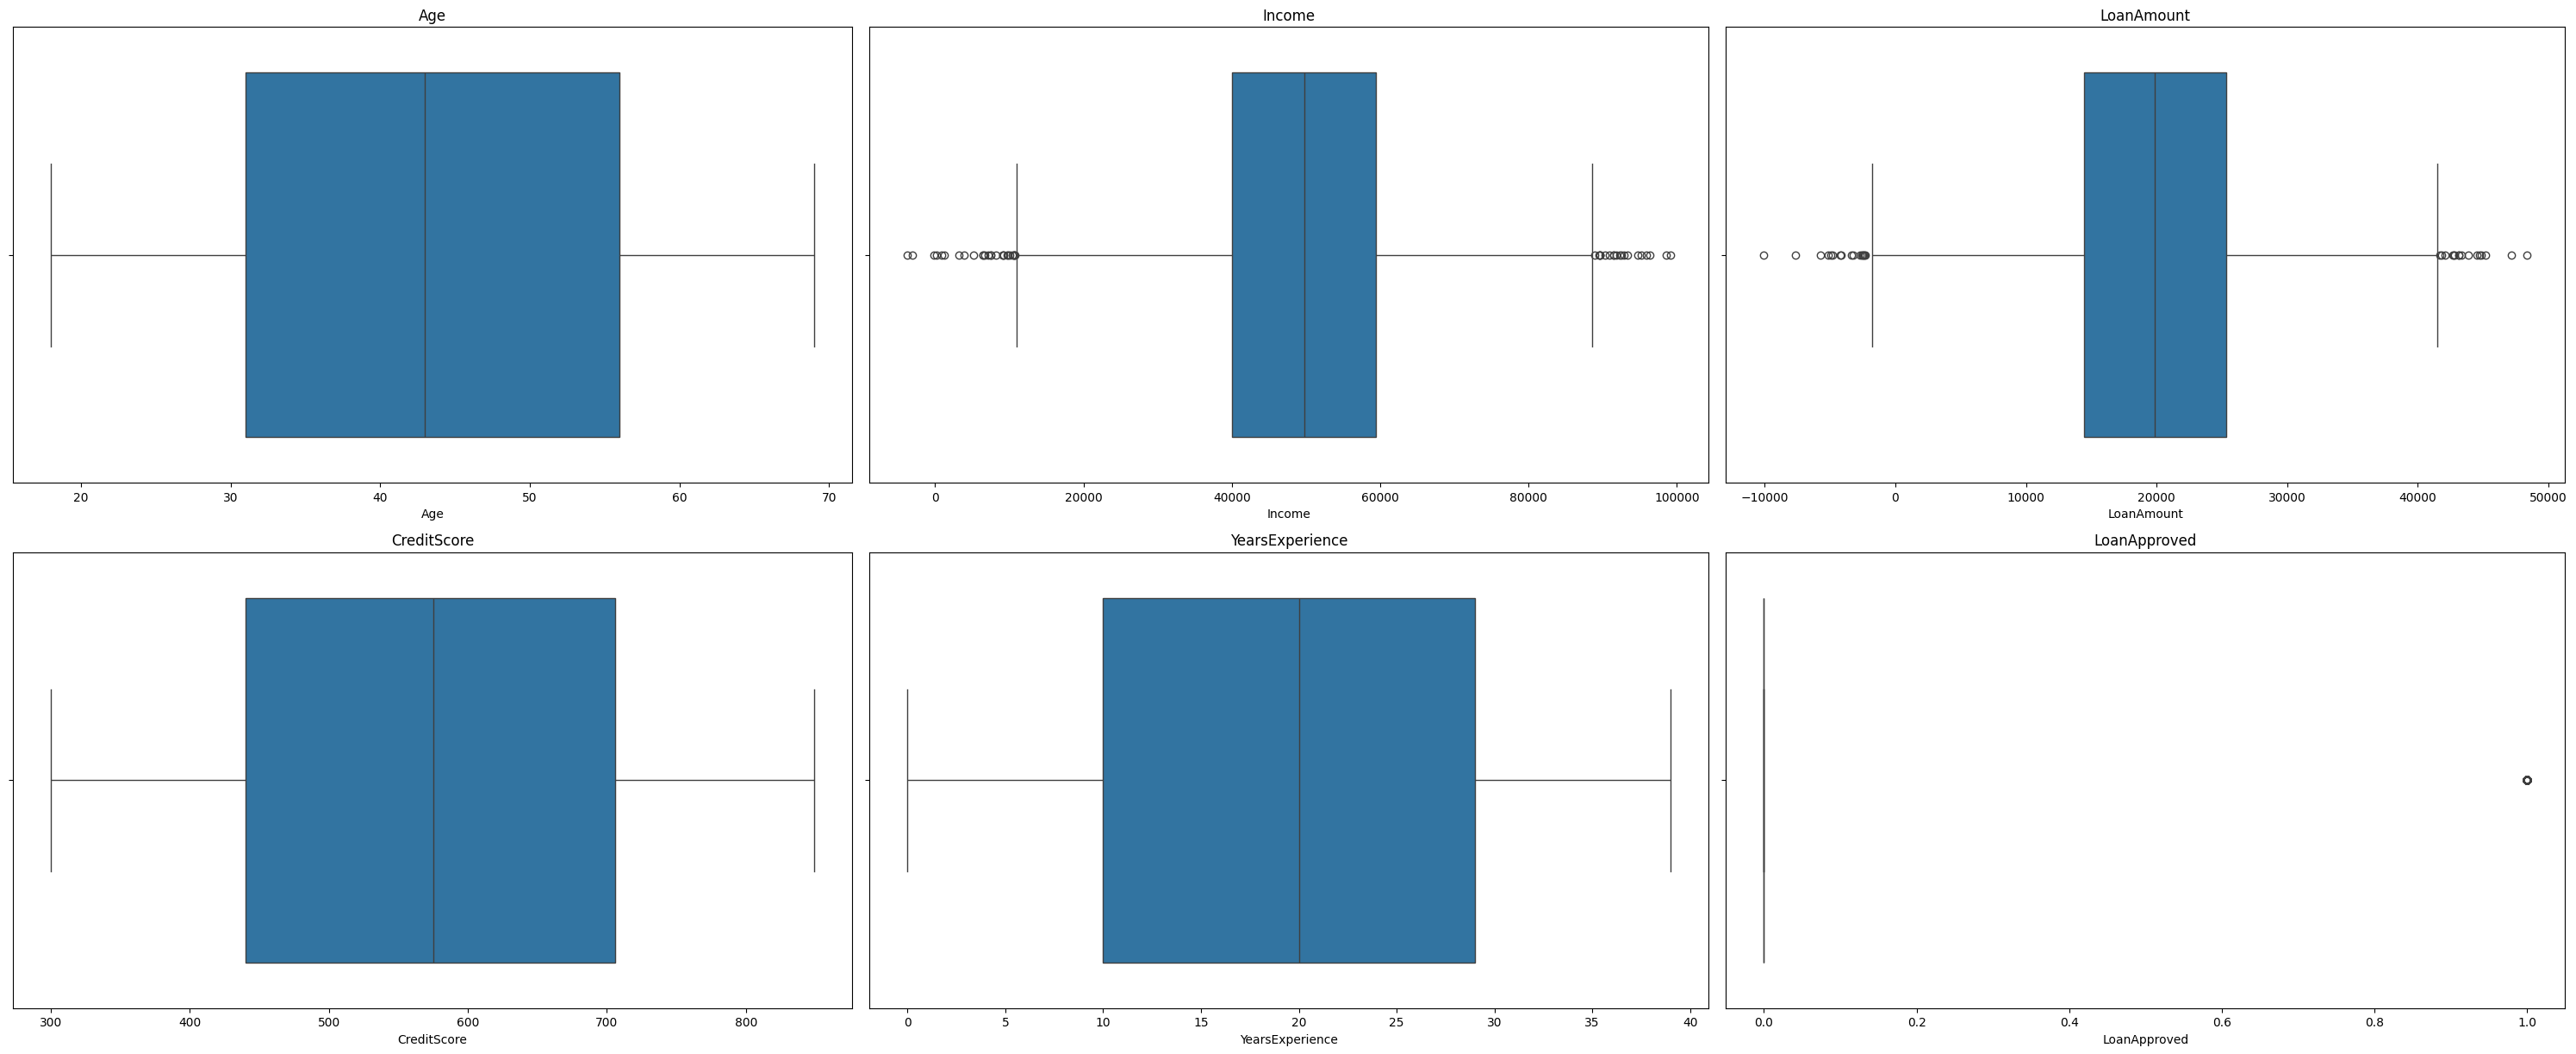

In [ ]:
plt.figure(figsize=(30,18))

for i,col in enumerate(num_col):
  plt.subplot(3,3,i+1)
  sns.boxplot(x=df[col])
  plt.title(col)
  plt.tight_layout()
plt.show()

In [ ]:
# Total number of outliers
outlier_count = {}

for col in num_col:

  Q1 = df[col].quantile(0.25)
  Q3 = df[col].quantile(0.75)

  IQR = Q3 - Q1

  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR

  outlier = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
  outlier_count[col] = len(outlier)

print('Number of outlier:')
pd.DataFrame([{'columns': i,'No of outliers': outlier } for i,outlier in outlier_count.items()])

Number of outlier:


,columns,No of outliers
0,Age,0
1,Income,47
2,LoanAmount,32
3,CreditScore,0
4,YearsExperience,0
5,LoanApproved,1151


In [ ]:
cat_col

['Gender', 'Education', 'City', 'EmploymentType']

In [ ]:
encod = [LabelEncoder() for i in cat_col]

for i,col in enumerate(cat_col):
  df[col] = encod[i].fit_transform(df[col])

In [ ]:
df.head()

,Age,Income,LoanAmount,CreditScore,YearsExperience,Gender,Education,City,EmploymentType,LoanApproved
0,56,48353.0,31258.0,675.0,20,0,1,1,2,0
1,69,57462.0,23262.0,586.0,6,1,1,3,1,0
2,46,44219.0,26530.0,781.0,26,1,3,1,1,1
3,32,56307.0,11531.0,549.0,11,1,0,2,2,0
4,60,37034.0,27871.0,500.0,19,0,1,0,2,0


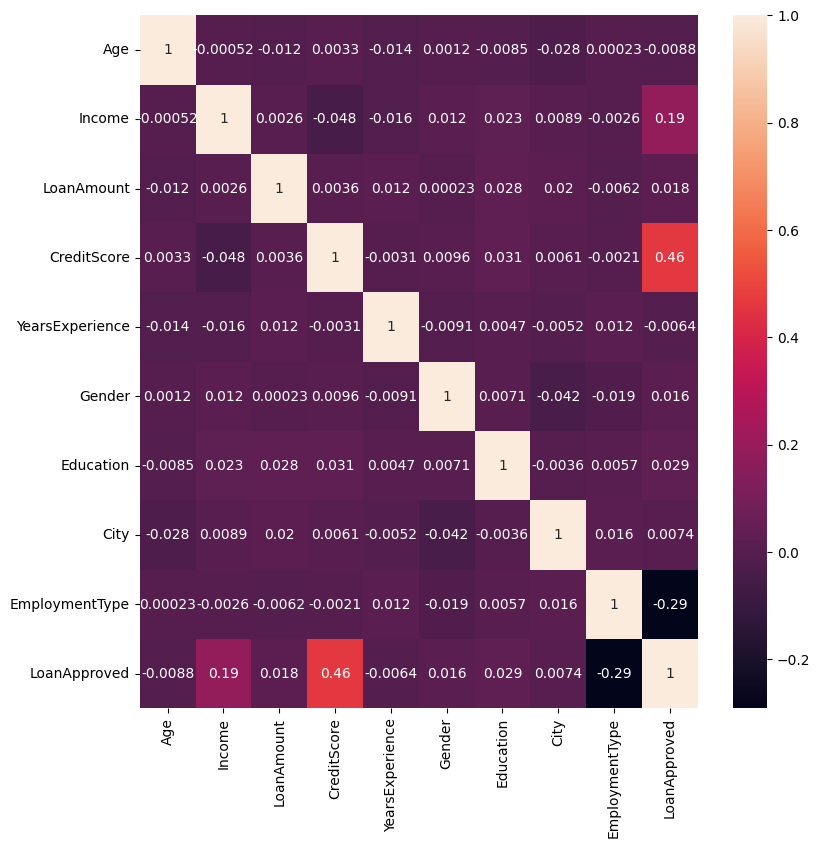

In [ ]:
plt.figure(figsize=(9,9))
sns.heatmap(df.corr(),annot=True);

In [ ]:
df.drop('City',axis=1,inplace=True)

In [ ]:
X = df.drop('LoanApproved',axis=1)
X

,Age,Income,LoanAmount,CreditScore,YearsExperience,Gender,Education,EmploymentType
0,56,48353.0,31258.0,675.0,20,0,1,2
1,69,57462.0,23262.0,586.0,6,1,1,1
2,46,44219.0,26530.0,781.0,26,1,3,1
3,32,56307.0,11531.0,549.0,11,1,0,2
4,60,37034.0,27871.0,500.0,19,0,1,2
...,...,...,...,...,...,...,...,...
4995,24,36780.0,23383.0,575.0,23,1,2,0
4996,66,99146.0,9760.0,306.0,14,1,3,2
4997,26,58100.0,18230.0,311.0,10,0,1,1
4998,53,58513.0,12373.0,813.0,23,1,3,0


In [ ]:
y = df['LoanApproved']
y

,LoanApproved
0,0
1,0
2,1
3,0
4,0
...,...
4995,0
4996,0
4997,0
4998,1


In [ ]:
df['LoanApproved'].value_counts()

,count
LoanApproved,
0,3849
1,1151


In [ ]:
from imblearn.over_sampling import SMOTE
OS = SMOTE()
x_os,y_os = OS.fit_resample(X,y)


In [ ]:
y_os.value_counts()

,count
LoanApproved,
0,3849
1,3849


In [ ]:
scale = StandardScaler()
x_scaled = scale.fit_transform(x_os)

In [ ]:
x_scaled

array([[ 0.91610811, -0.23000145,  1.41343026, ..., -0.87382715,
        -0.30206562,  1.57350227],
       [ 1.85240661,  0.41821604,  0.42193261, ...,  1.14439109,
        -0.30206562,  0.30047857],
       [ 0.1958785 , -0.52418645,  0.82716201, ...,  1.14439109,
         1.56414718,  0.30047857],
       ...,
       [-1.24458072,  1.75876574, -0.93440037, ..., -0.87382715,
        -0.30206562, -0.97254513],
       [-0.23625926,  0.032652  , -0.38616479, ...,  1.14439109,
         0.63104078, -0.97254513],
       [-1.24458072, -0.29879018, -1.28237376, ...,  1.14439109,
        -0.30206562, -0.97254513]])

In [ ]:
x_train,x_test,y_train,y_test = train_test_split(x_os,y_os,test_size=0.3,random_state=2)

In [ ]:
x_train.shape,y_train.shape

((5388, 8), (5388,))

In [ ]:
x_test.shape,y_test.shape

((2310, 8), (2310,))

In [ ]:
def report(test,pred):
  print('\n Classification report:')
  print(classification_report(test,pred))
  print('\n Confusion Metrics:')
  print(ConfusionMatrixDisplay.from_predictions(test,pred))

## Logistic Regression

In [ ]:
lr = LogisticRegression(random_state=2)
lr.fit(x_train,y_train)

LogisticRegression(random_state=2)


 Classification report:
              precision    recall  f1-score   support

           0       0.83      0.78      0.81      1172
           1       0.79      0.84      0.81      1138

    accuracy                           0.81      2310
   macro avg       0.81      0.81      0.81      2310
weighted avg       0.81      0.81      0.81      2310


 Confusion Metrics:


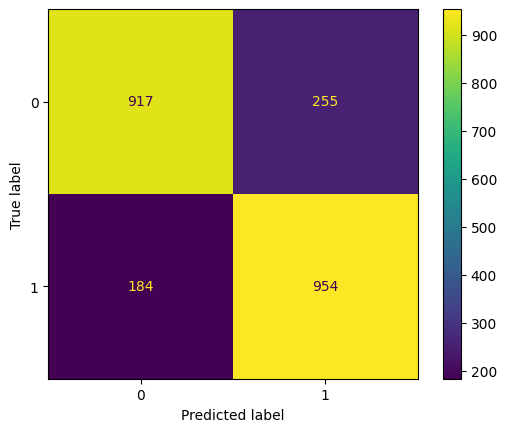

In [ ]:
y_pred_lr = lr.predict(x_test)
report(y_test,y_pred_lr)

## KNN Classifier

In [ ]:
knn = KNeighborsClassifier()
knn.fit(x_train,y_train)

KNeighborsClassifier()


 Classification report:
              precision    recall  f1-score   support

           0       0.77      0.64      0.70      1172
           1       0.68      0.80      0.74      1138

    accuracy                           0.72      2310
   macro avg       0.73      0.72      0.72      2310
weighted avg       0.73      0.72      0.72      2310


 Confusion Metrics:


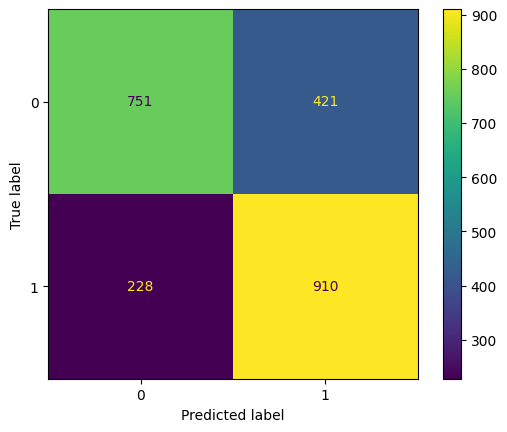

In [ ]:
y_pred_knn = knn.predict(x_test)
report(y_test,y_pred_knn)

## Naive bias Classifier

In [ ]:
nb = GaussianNB()
nb.fit(x_train,y_train)

GaussianNB()


 Classification report:
              precision    recall  f1-score   support

           0       0.91      0.88      0.90      1172
           1       0.88      0.92      0.90      1138

    accuracy                           0.90      2310
   macro avg       0.90      0.90      0.90      2310
weighted avg       0.90      0.90      0.90      2310


 Confusion Metrics:


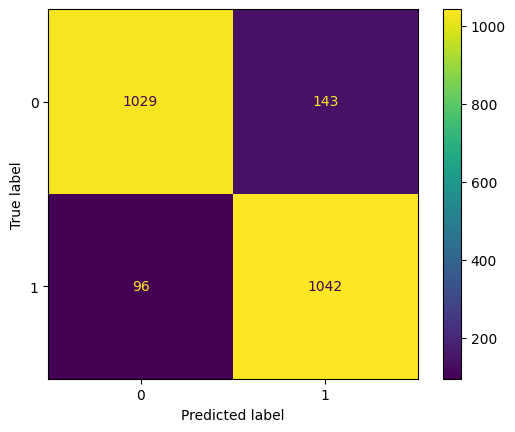

In [ ]:
y_pred_nb = nb.predict(x_test)
report(y_test,y_pred_nb)

In [ ]:
nb.score(x_train,y_train)

0.8988492947290274

## Decision Tree Classifier

In [ ]:
dt = DecisionTreeClassifier(random_state=42,criterion='entropy')
dt.fit(x_train,y_train)

DecisionTreeClassifier(criterion='entropy', random_state=42)


 Classification report:
              precision    recall  f1-score   support

           0       0.93      0.92      0.92      1172
           1       0.92      0.93      0.92      1138

    accuracy                           0.92      2310
   macro avg       0.92      0.92      0.92      2310
weighted avg       0.92      0.92      0.92      2310


 Confusion Metrics:


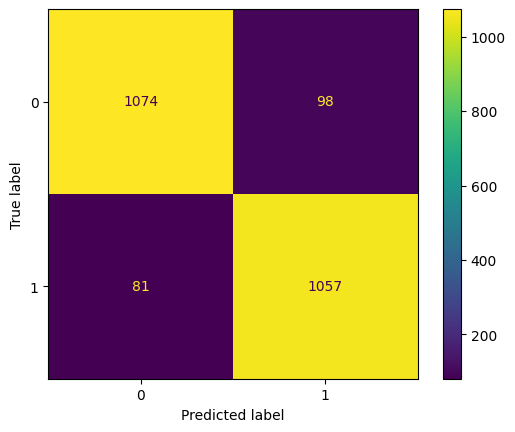

In [ ]:
y_pred_dt = dt.predict(x_test)
report(y_test,y_pred_dt)

In [ ]:
dt.score(x_train,y_train)

1.0

# Ensamble Models

## Random Forest Classifier

In [ ]:
rf = RandomForestClassifier(random_state=2,criterion='entropy')
rf.fit(x_train,y_train)

RandomForestClassifier(criterion='entropy', random_state=2)


 Classification report:
              precision    recall  f1-score   support

           0       0.93      0.99      0.96      1172
           1       0.99      0.93      0.96      1138

    accuracy                           0.96      2310
   macro avg       0.96      0.96      0.96      2310
weighted avg       0.96      0.96      0.96      2310


 Confusion Metrics:


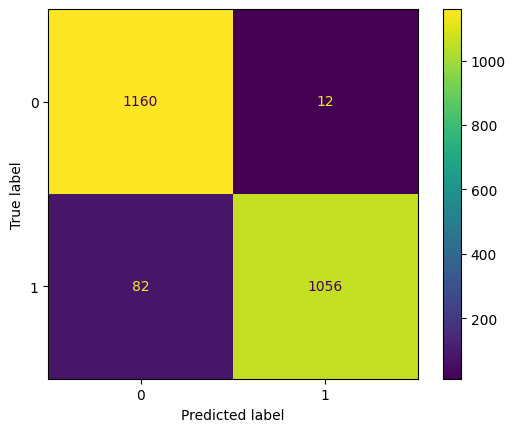

In [ ]:
y_pred_rf = rf.predict(x_test)
report(y_test,y_pred_rf)

In [ ]:
rf.score(x_train,y_train)

1.0


AdaBoostClassifier():

 Classification report:
              precision    recall  f1-score   support

           0       0.93      0.88      0.90      1172
           1       0.88      0.93      0.91      1138

    accuracy                           0.91      2310
   macro avg       0.91      0.91      0.91      2310
weighted avg       0.91      0.91      0.91      2310


 Confusion Metrics:
0.9097995545657016

GradientBoostingClassifier():

 Classification report:
              precision    recall  f1-score   support

           0       0.92      0.99      0.95      1172
           1       0.99      0.91      0.95      1138

    accuracy                           0.95      2310
   macro avg       0.95      0.95      0.95      2310
weighted avg       0.95      0.95      0.95      2310


 Confusion Metrics:
0.9600965107646622

BaggingClassifier():

 Classification report:
              precision    recall  f1-score   support

           0       0.93      0.98      0.96      1172
      

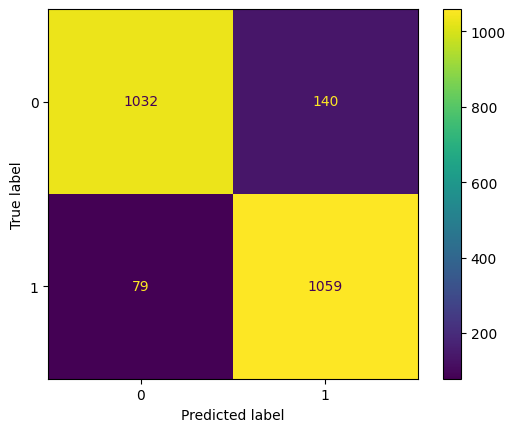

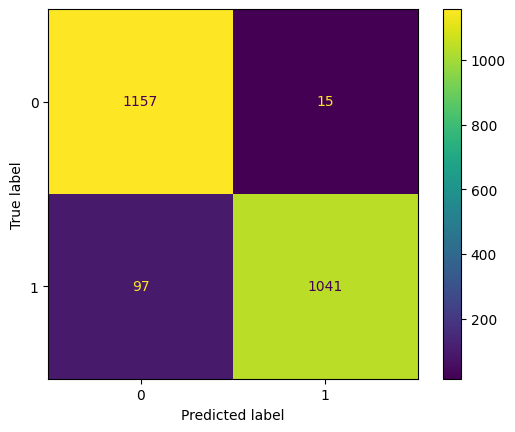

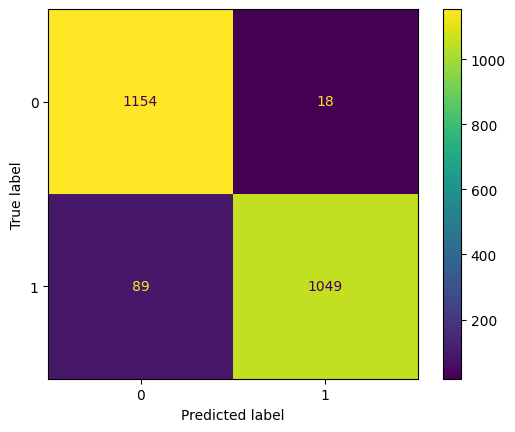

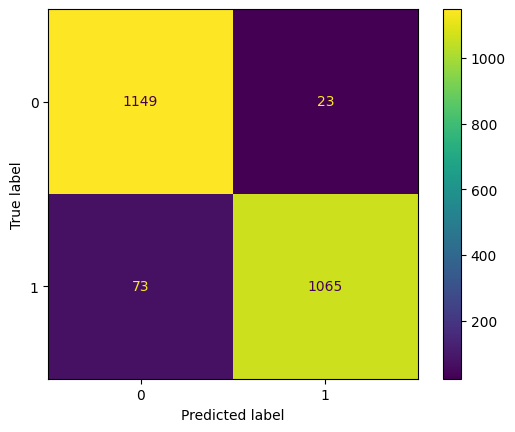

In [ ]:
models = [AdaBoostClassifier(),GradientBoostingClassifier(),BaggingClassifier(),XGBClassifier()]

for i,model in enumerate(models):
  models[i].fit(x_train,y_train)
  y_pred = models[i].predict(x_test)
  print(f'\n{model}:')
  report(y_test,y_pred)
  print(models[i].score(x_train,y_train))




 Classification report:
              precision    recall  f1-score   support

           0       0.92      0.99      0.95      1172
           1       0.99      0.91      0.95      1138

    accuracy                           0.95      2310
   macro avg       0.95      0.95      0.95      2310
weighted avg       0.95      0.95      0.95      2310


 Confusion Metrics:


0.9600965107646622

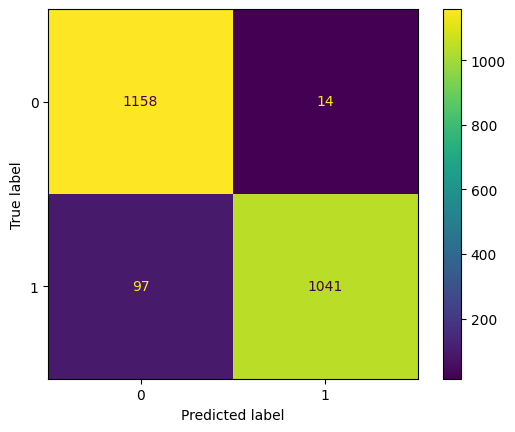

In [ ]:
Gb = GradientBoostingClassifier()
Gb.fit(x_train,y_train)
y_pred_gb = Gb.predict(x_test)
report(y_test,y_pred_gb)
Gb.score(x_train,y_train)

## Gradient Boosting Classifier Model Tuning

In [ ]:
param = {'loss': ['log_loss', 'exponential'],
    'learning_rate': [0.001,0.1],
    'n_estimators': [50,80],
    'max_depth': [ 5, 7],
         'random_state':[2,42]}

In [ ]:
GCV = GridSearchCV(Gb,param,cv=3,scoring='accuracy')
GCV.fit(x_train,y_train)

GridSearchCV(cv=3, estimator=GradientBoostingClassifier(),
             param_grid={'learning_rate': [0.001, 0.1],
                         'loss': ['log_loss', 'exponential'],
                         'max_depth': [5, 7], 'n_estimators': [50, 80],
                         'random_state': [2, 42]},
             scoring='accuracy')

In [ ]:
GCV.best_params_

{'learning_rate': 0.1,
 'loss': 'exponential',
 'max_depth': 7,
 'n_estimators': 80,
 'random_state': 2}

In [ ]:
y_pred_GCV = GCV.predict(x_test)

In [ ]:
print(classification_report(y_test,y_pred_GCV))

              precision    recall  f1-score   support

           0       0.93      0.98      0.96      1172
           1       0.98      0.93      0.95      1138

    accuracy                           0.96      2310
   macro avg       0.96      0.96      0.96      2310
weighted avg       0.96      0.96      0.96      2310



In [ ]:
GCV.score(x_train,y_train)

0.9925760950259837